In [1]:
from langgraph.graph import START, END, StateGraph
from typing import TypedDict

In [ ]:
from dotenv import load_dotenv
import os
load_dotenv()

In [20]:
class ReflectState(TypedDict):
    original_task: str
    current_draft: str
    
    latest_critique: bool
    critique_summary: str
    
    current_iteration: int
    limit_iteration: int

In [ ]:
from langchain_groq import ChatGroq
generator_llm = ChatGroq(model='llama-3.1-8b-instant',
                     api_key=os.getenv('GROQ_API_KEY')) #type: ignore

critique_llm = ChatGroq(model='openai/gpt-oss-20b',
                    api_key=os.getenv('GROQ_API_KEY')) #type: ignore

In [10]:
def generator(state: ReflectState):
    org_task = state['original_task']
    critique_summary = state.get('critique_summary', None)
    if critique_summary is None:
        response = generator_llm.invoke([
            ('system', 'You are a helpful writer. Respond only with answer, no words like: here is your answer, ...'),
            ('user', f'task: {org_task}')
        ])
    else:
        response = generator_llm.invoke([
            ('system', 'You are a helpful writer. Only respond with answer no words like: here is your answer, ...'),
            ('user', 
             f"""
             task: {org_task}
             previous critique summary: {critique_summary}""")
        ])
    return {'current_draft': response.content}

In [21]:
def critique(state: ReflectState):
    org_task = state['original_task']
    critique_summary = state.get('critique_summary', 'no previous summary')
    current_draft = state['current_draft']
    
    critique_response = critique_llm.invoke([
        ('system', 'You are a helpful critique. Respond only with answer, no words like here is your critique'),
        ('user',
         f"""
         Task: {org_task}
         Previous critiques summary: {critique_summary}
         Current draft: {current_draft}
         Critique this draft. If it's good enough, respond only DONE
         """)
    ])
    
    latest_critique = critique_response.content
    
    if latest_critique == 'DONE':
        return {
            'latest_critique': 'DONE',
        }
    
    summary_response = critique_llm.invoke([
        ('system', 'You are a helpful assistant'),
        ('user',
         f"""
         Summarize this critique into existing summary critique
         
         Latest critique: {latest_critique}
         
         Summary critique: {critique_summary}
         """)
    ])
    
    new_critique_summary = summary_response.content
    
    return {
        'critique_summary': new_critique_summary,
        'current_iteration': state.get('current_iteration', 0) + 1,
        'latest_critique': latest_critique,
    }
    

In [33]:
def router(state: ReflectState):
    current_iteration = state.get('current_iteration', 0)
    latest_critique = state.get('latest_critique', None)
    limit_iteration = state['limit_iteration']
    if latest_critique == 'DONE' or current_iteration >= limit_iteration:
        return 'DONE'
    return 'CRITIQUE'

In [39]:
graph = StateGraph(ReflectState)

#add nodes
graph.add_node('generator', generator)
graph.add_node('critique', critique)

#add edges
graph.add_edge(START, 'generator')

graph.add_conditional_edges(
    'generator',
    router,
    {
        'DONE': END,
        'CRITIQUE': 'critique'
    }
)
graph.add_edge('critique', 'generator')

app = graph.compile()

In [40]:
from IPython.display import display, Image
def draw_png(app):
    display(Image(app.get_graph().draw_mermaid_png()))

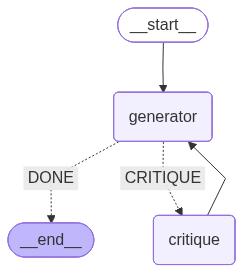

In [41]:
draw_png(app)

In [42]:
request = {
    'original_task': 'Create a short mystery story (under 1000 words) about a young boy get lost when camping with his friends.',
    'limit_iteration': 3,
    'current_draft': '', 
    'latest_critique': '',
    'critique_summary': '',
    'current_iteration': 0,
    
}

In [43]:
result = app.invoke(request)

In [44]:
result

{'original_task': 'Create a short mystery story (under 1000 words) about a young boy get lost when camping with his friends.',
 'current_draft': 'The woods had always been a place of wonder for 12-year-old Jack. He, along with his friends Alex, Emily, and Matt, had been planning this camping trip for months. As they hiked deeper into the forest, the trees seemed to close in around them, casting dappled shadows on the ground. The crunch of leaves and snapping of twigs beneath their feet served as a reminder that they were not alone.\n\n"Hey, guys, look at this!" Jack exclaimed, stopping in front of a massive tree with a strange symbol etched into its trunk. The others gathered around, their faces lit up with curiosity.\n\n"What is it?" Emily asked, her voice barely above a whisper.\n\n"I don\'t know," Jack replied, "but it looks ancient."\n\nAs they continued on their hike, the symbol lingered in their minds. Alex, ever the skeptic, joked that it was probably just some high school prank